# Task 2 Regression

In [1]:
import matplotlib.pyplot as plt, numpy as np, os, torch, random, cv2, json
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torchvision import models
from torchvision.transforms import v2 as transforms
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, r2_score

random.seed(42)

## Load dataset

**Tip**: since the images are very big, resize the dataset before loading it to save time and memory during training (use cubic interpolation to preserve image quality when downsizing the images)!

In [2]:
# Normalize images
data_aug = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.15)),
    transforms.CenterCrop((224, 224)),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

data_in = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)), # fixed size crop to image, since board isn't near borders usually, and there are missleading pieces in the sides
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [3]:
def chesspos2number(chesspos):
    col = ord(chesspos[0])-ord('a')
    row = int(chesspos[1])-1
    return row, col

class ChessDataset(Dataset):
    def __init__(self, root_dir, partition, transform=None):
        self.anns = json.load(open(os.path.join(root_dir, 'annotations.json')))
        self.categories = [c['name'] for c in self.anns['categories']]
        self.root = root_dir
        self.ids = []
        self.file_names = []
        for x in self.anns['images']:
            self.file_names.append(x['path'])
            self.ids.append(x['id'])
        self.file_names = np.asarray(self.file_names)
        self.ids = np.asarray(self.ids)
        self.boards = torch.zeros((len(self.file_names), 8, 8))
        for piece in self.anns['annotations']['pieces']:
            idx = np.where(self.ids == piece['image_id'])[0][0]
            row, col = chesspos2number(piece['chessboard_position'])
            self.boards[idx][row][col] = 1

        if partition == 'train':
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['train']['image_ids']).astype(int)
        elif partition == 'valid':
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['val']['image_ids']).astype(int)
        else:
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['test']['image_ids']).astype(int)

        intersect = np.isin(self.ids, self.split_ids)
        self.split_ids = np.where(intersect)[0]
        self.file_names = self.file_names[self.split_ids]
        self.boards = self.boards[self.split_ids]
        self.num_pieces = torch.sum(self.boards.view(len(self.boards), 64), axis=-1)
        self.ids = self.ids[self.split_ids]

        self.transform = transform
        print(f"Number of {partition} images: {len(self.file_names)}")

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, i):
        image = cv2.imread(os.path.join(self.root, self.file_names[i]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        num_pieces = self.num_pieces[i]

        return image, num_pieces.float()

train_dataset = ChessDataset('./', 'train', data_aug)
valid_dataset = ChessDataset('./', 'valid', data_in)
test_dataset = ChessDataset('./', 'test', data_in)

Number of train images: 1442
Number of valid images: 330
Number of test images: 306


In [4]:
# get cpu or gpu device for training
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# now we need to define a Dataloader, which allows us to automatically batch our inputs, do sampling and multiprocess data loading
batch_size = 16
num_workers = 0 # changed for mac # how many processes are used to load the data


Using mps device


In [5]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=False)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)

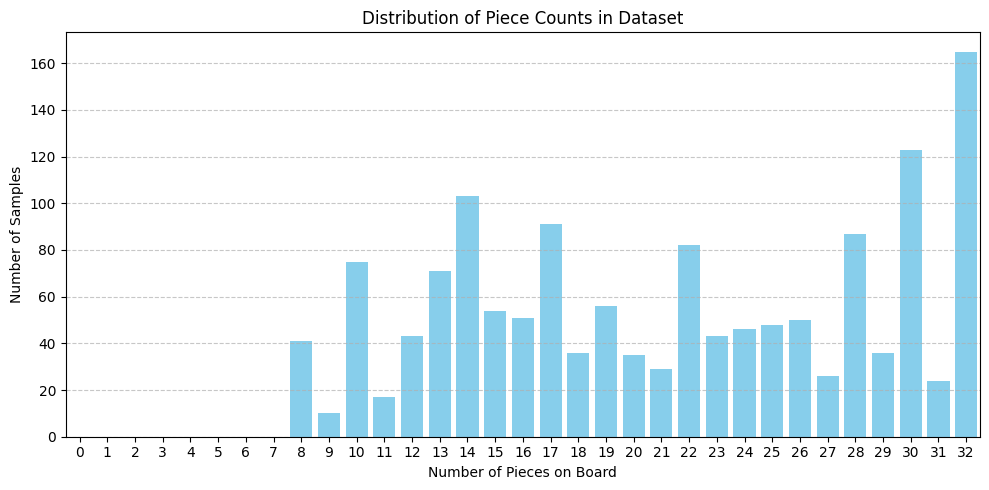

Min pieces: 8
Max pieces: 32
Mean: 21.31
Std: 7.44


In [6]:
# Understanding the dataset

# For any dataset (train_dataset, valid_dataset, test_dataset)
train_pieces_count = train_dataset.num_pieces.int().numpy()

# Count how many times each number (0 to 32) occurs
counts = np.bincount(train_pieces_count, minlength=33)

# Create an array for the x-axis (piece counts)
piece_counts = np.arange(33)

# Plot it
plt.figure(figsize=(10, 5))
plt.bar(piece_counts, counts, color="skyblue")
plt.xlabel("Number of Pieces on Board")
plt.ylabel("Number of Samples")
plt.title("Distribution of Piece Counts in Dataset")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(piece_counts)
plt.xlim(-0.5, 32.5)
plt.tight_layout()
plt.show()

print(f"Min pieces: {train_pieces_count.min()}")
print(f"Max pieces: {train_pieces_count.max()}")
print(f"Mean: {train_pieces_count.mean():.2f}")
print(f"Std: {train_pieces_count.std():.2f}")

In [22]:
from torch.utils.data import WeightedRandomSampler

# get counts of each piece count
piece_counts = [int(n.item()) for n in train_dataset.num_pieces]
unique, counts = np.unique(piece_counts, return_counts=True)
freq = dict(zip(unique, counts))

# inverse frequency weights
weights = [1.0 / freq[count] for count in piece_counts]

# oversample rare piece counts in train_data, to make each piece count equally represented
# NOTE: this is almost like having a new sample each time the same underrepresented piece is used, because it is subject to new augmentations
train_sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers, drop_last=False)

In [15]:
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)

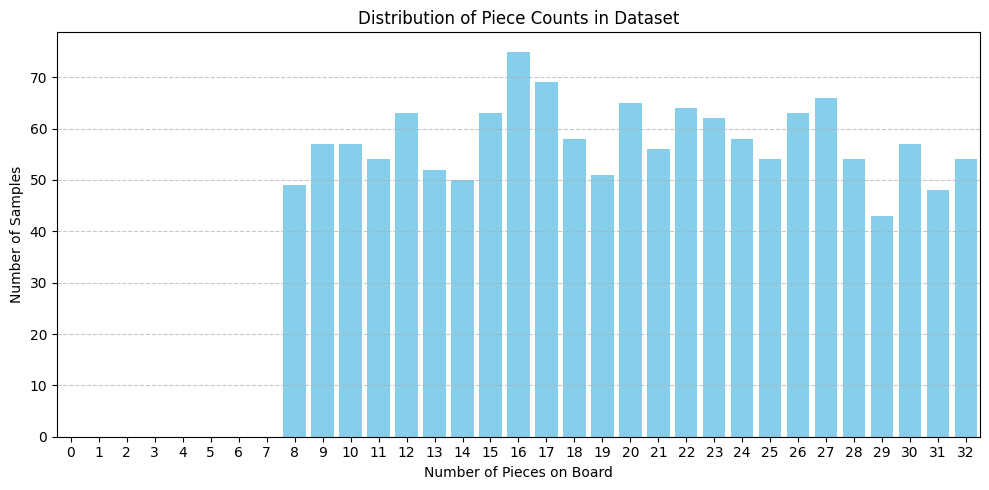

Min pieces: 8
Max pieces: 32
Mean: 19.90
Std: 7.01


In [23]:
# understanding the dataset 
# compare new dataset sampler distribution
num_test_samples = len(train_dataset) # 1:1 size comparison

# collect piece counts of sampled items
sampled_piece_counts = []

total_collected = 0
for batch in train_dataloader:
    labels = batch[1]  # we only need labels
    labels = labels.int().tolist()
    sampled_piece_counts.extend(labels)
    total_collected += batch_size
    if total_collected >= num_test_samples:
        break

# trim excess samples
sampled_piece_counts = sampled_piece_counts[:num_test_samples]

# count how many times each number (0 to 32) occurs
counts = np.bincount(sampled_piece_counts, minlength=33)

# create an array for the x-axis (piece counts)
piece_counts = np.arange(33)

# Plot it
plt.figure(figsize=(10, 5))
plt.bar(piece_counts, counts, color="skyblue")
plt.xlabel("Number of Pieces on Board")
plt.ylabel("Number of Samples")
plt.title("Distribution of Piece Counts in Dataset")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(piece_counts)
plt.xlim(-0.5, 32.5)
plt.tight_layout()
plt.show()

print(f"Min pieces: {min(sampled_piece_counts)}")
print(f"Max pieces: {max(sampled_piece_counts)}")
print(f"Mean: {np.mean(sampled_piece_counts):.2f}")
print(f"Std: {np.std(sampled_piece_counts):.2f}")

torch.Size([16, 224, 224, 3])
tensor([24., 27., 25., 22., 15., 12., 19., 30., 19., 31., 28., 23., 30., 32.,
        10., 23.])
torch.Size([16])
Piece count: 24


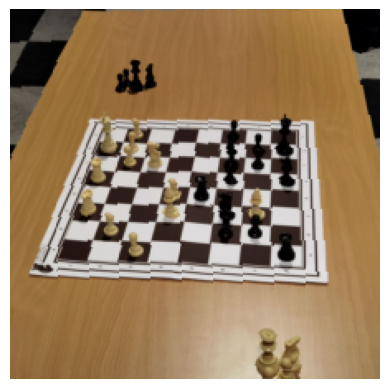

In [31]:
for batch in train_dataloader:
    # Get images of the batch and print their dimensions
    imgs = batch[0] # imgs have format [batch_size, channels, height, width]
    imgs = imgs.permute(0, 2, 3, 1)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]]) # changing format to [batch_size, height, width, channels] # also, use ImageNet normalization stats of mean and std dev
    print(imgs.shape)

    # Get labels of each image in the batch and print them
    labels = batch[1]
    print(labels)
    print(labels.shape)

    # Show first image of the batch
    plt.imshow(imgs[0])
    print("Piece count:", int(labels[0]))
    plt.axis('off')
    plt.show()

    break